# 05 — Error analysis and limits: *Where the model fails, and what moves it*

The full model (notebook 04) has one clear weakness: the **rating extremes**. It over-predicts
players below 1200 by about +300 Elo and under-predicts players at 2000+ by about −250, while the four
middle bands have MAE between about 187 and 219. The two extreme bands hold about 40% of the test
games, so this is not a corner case. This notebook asks whether that error can be fixed, and how.

**Plan.**
1. The symptom: residual and MAE by rating band.
2. What can be done at the **single-game** level: a calibration check (is there shrinkage left
   to undo?), reweighting the training data toward rare ratings, clock-scramble features, and — for
   the interval — band-conditional (Mondrian) conformal correction.
3. What **several games** do: plain averaging leaves the bias; a K-aware recalibration reduces it.
4. Robustness checks: leakage through shared games, error vs game length, confidence intervals,
   sensitivity checks, and the confirmatory hold-out.
5. The worst single-game misses.
6. The confirmatory hold-out, and the limitations of the study.

In [1]:
# --- Setup: paths, style, and the shared save-and-show helper -------------------------------
import sys, json, warnings
from pathlib import Path

# Make `import src...` work whether the notebook is run from notebooks/ or the repo root.
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.config import load_config
from src.plotting import set_style, save_fig
import re

warnings.filterwarnings("ignore")          # keep library chatter out of the rendered notebook
cfg = load_config()
set_style()                                 # one house style for every figure
OUT = cfg["outputs"]                        # every data/report path comes from config.yaml
FIGROOT = Path(cfg["paths"]["figures"])
FIG = FIGROOT / "notebook_05_limits"                  # this notebook's figure folder (auto-created)
BANDS = cfg["rating_bands"]

def show(path):
    "Display a figure that save_fig() just wrote to reports/figures/."
    display(Image(filename=str(path)))

A = json.loads(Path(OUT["eval_artifacts"]).read_text(encoding="utf-8"))
LABELS = [b["band"] for b in A["residual_by_band"]]

def latest_md_section(substr):
    "The newest reports/results.md entry whose heading contains `substr`."
    blocks = re.split(r"(?m)^## ", Path(OUT["results_log"]).read_text(encoding="utf-8"))[1:]
    hits = [b for b in blocks if substr in b.splitlines()[0]]
    return hits[-1] if hits else None

RUN_HEAVY = False   # True: regenerate the tail study live via src.evaluate.run_tail_study (~2 min)
if RUN_HEAVY:
    from src.evaluate import run_tail_study
    run_tail_study(cfg, OUT["features"], OUT["games_clean"], results_md=OUT["results_log"])

print("artifact from commit:", A["source_commit"], "| test instances:", f"{A['n_test']:,}")

artifact from commit: 33171ec | test instances: 120,513


## 1. The symptom: residual by rating band

For each *true* rating band: the mean residual (prediction − actual; + means over-predicted) and
the band MAE.

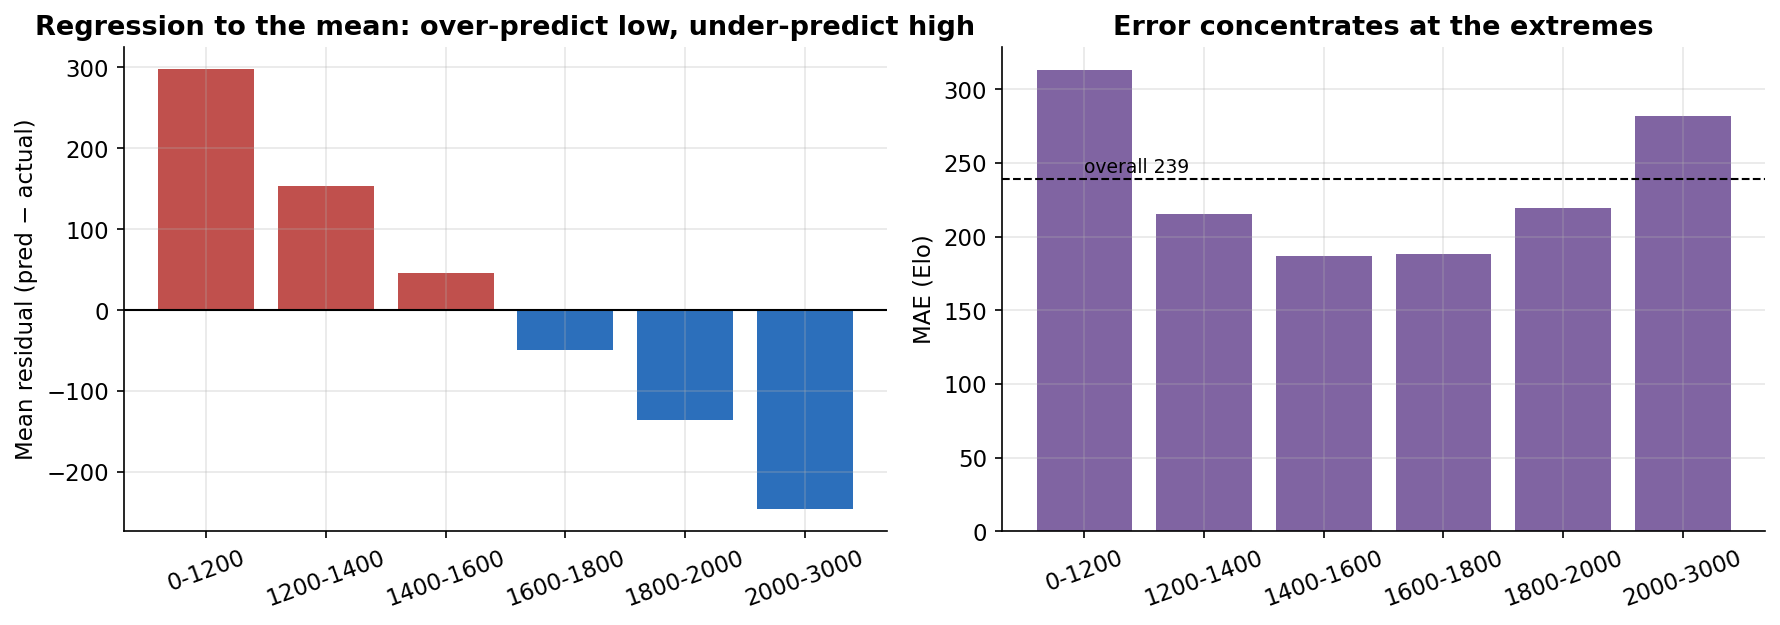

,band,n,mean_residual,mae,share of test
0,0-1200,21267,297.957,313.014,0.176
1,1200-1400,15603,153.299,215.626,0.129
2,1400-1600,19149,46.250,186.704,0.159
3,1600-1800,19834,-48.776,188.389,0.165
4,1800-2000,17479,-135.449,219.395,0.145
5,2000-3000,27181,-246.085,281.522,0.226


In [2]:
rbb = pd.DataFrame(A["residual_by_band"])
rbb["share of test"] = rbb["n"] / rbb["n"].sum()
x = np.arange(len(rbb))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
ax1.bar(x, rbb["mean_residual"], color=["#c0504d" if v > 0 else "#2c6fbb" for v in rbb["mean_residual"]])
ax1.axhline(0, color="k", lw=1)
ax1.set_xticks(x); ax1.set_xticklabels(rbb["band"], rotation=20)
ax1.set(ylabel="Mean residual (pred − actual)", title="Regression to the mean: over-predict low, under-predict high")
ax2.bar(x, rbb["mae"], color="#8064a2")
ax2.axhline(A["full_mae"], color="k", ls="--", lw=1); ax2.text(0, A["full_mae"] + 4, f"overall {A['full_mae']:.0f}", fontsize=9)
ax2.set_xticks(x); ax2.set_xticklabels(rbb["band"], rotation=20)
ax2.set(ylabel="MAE (Elo)", title="Error concentrates at the extremes")
fig.tight_layout()
show(save_fig(fig, "limits_residual_by_band", FIG))
display(rbb.round(3))

**Reading it.** The mean residual goes from about **+298** (below 1200) to about **−246** (2000+),
crossing zero in the middle — the signature of regression to the mean. Band MAE is U-shaped: about
313 at the bottom, 187–188 in the middle, 282 at the top. Is this a *correctable bias*, or the
*right* response to weak single-game evidence?

## 2a. Single game — leftover shrinkage, and reweighting toward rare ratings

Two checks, both in `src.evaluate.run_tail_study`, compared band by band with the plain model:

- **Calibration check.** If the model shrank toward the mean *more than the evidence justifies*,
  regressing the true rating on the prediction (on held-out calibration data) would give a slope
  above 1, and stretching the predictions by that line would help. The `deshrink` row applies the
  fitted line.
- **Reweighting.** Up-weight rare ratings during training: each instance gets weight
  (1 / frequency of its 100-Elo rating bin)^0.5, so the extremes count more (printed below).

,overall,tail,mid,0-1200,1200-1400,1400-1600,1600-1800,1800-2000,2000-3000
variant,,,,,,,,,
plain,239.1,297.0,203.0,313.0,216.0,187.0,188.0,219.0,282.0
"reweighted(100-Elo bins, s=0.5)",245.6,271.0,230.0,279.0,231.0,222.0,224.0,243.0,262.0
deshrink(slope=0.96),239.5,305.0,198.0,322.0,214.0,181.0,182.0,215.0,288.0


single-game line true ~ prediction (calibration split): slope 0.961 (95% CI 0.946-0.976, player-clustered bootstrap), intercept 63
reweighted: mean training weight by band: 0-1200 1.30, 1200-1400 0.86, 1400-1600 0.78, 1600-1800 0.78, 1800-2000 0.83, 2000-3000 1.27


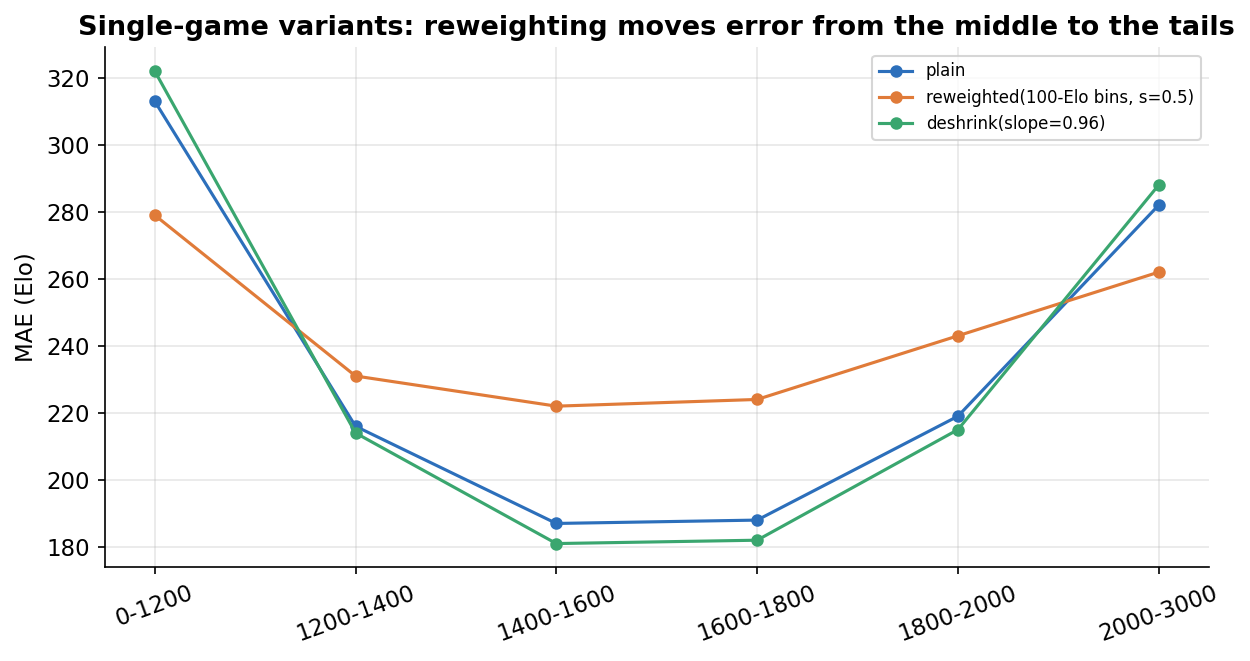

In [3]:
tail_block = latest_md_section("tail study")
rows = [ln for ln in tail_block.splitlines() if ln.startswith("| ") and "variant" not in ln and "---" not in ln]
cols = ["variant", "overall", "tail", "mid"] + LABELS
tail = pd.DataFrame([[c.strip() for c in r.strip("| ").split("|")] for r in rows], columns=cols)
for c in cols[1:]:
    tail[c] = tail[c].astype(float)
display(tail.set_index("variant"))
sd = A["single_game_deshrink"]
print(f"single-game line true ~ prediction (calibration split): slope {sd['slope']:.3f} "
      f"(95% CI {sd['slope_lo']:.3f}-{sd['slope_hi']:.3f}, player-clustered bootstrap), intercept {sd['intercept']:.0f}")
weights_line = [ln for ln in tail_block.splitlines() if ln.startswith("- reweighted")]
print(weights_line[0][2:] if weights_line else "")

x = np.arange(len(LABELS))
fig, ax = plt.subplots(figsize=(9.5, 4.5))
palette = {"plain": "#2c6fbb", "reweighted": "#e07b39", "deshrink": "#3aa66f"}
for _, row in tail.iterrows():
    name = row["variant"]
    key = "plain" if name.startswith("plain") else ("reweighted" if "reweight" in name else "deshrink")
    ax.plot(x, [row[c] for c in LABELS], "-o", ms=5, color=palette[key], label=name)
ax.set_xticks(x); ax.set_xticklabels(LABELS, rotation=20)
ax.set(ylabel="MAE (Elo)", title="Single-game variants: reweighting moves error from the middle to the tails")
ax.legend(fontsize=8)
show(save_fig(fig, "limits_tail_study", FIG))

**Reading it.**

- **No leftover linear shrinkage.** The fitted slope is **0.96** (95% CI 0.946–0.976): slightly
  *below* 1, so on the calibration split the predictions are, if anything, a little too spread out,
  not too compressed. There is nothing to stretch: applying the fitted line pulls predictions slightly
  *further* in and worsens the tails (297 → 305 in the "tail" column, the average of the two extreme
  bands). This is a check of one straight line; the binned calibration plot (`reports/figures/calibration.png`)
  follows the diagonal. A model that predicts `E[true | predicted]` well *must* still show the
  conditional bias by true band when one game is weak evidence: for a player whose true rating is
  extreme, a good estimate from a noisy game lands closer to the centre.
- **Reweighting trades the middle for the tails.** With rare ratings up-weighted, the two extreme
  bands improve (below 1200: 313 → 279; 2000+: 282 → 262) but every middle band gets worse (by
  about 15 to 36 Elo), and overall MAE rises from 239.1 to 245.6. Reweighting chooses *whom* to be accurate
  for; it does not add information.

## 2b. Single game — clock-scramble features

Maybe the extremes differ in how they handle time pressure. Notebook 02 built a scramble block
(quality and tempo of moves made with under 30 s left). We retrain the model without the whole
block and compare, overall and in the two extreme bands.

scramble present: 26.9% of instances; scramble_cpl_delta median +8.3, mean +33.0 cpl


,overall MAE,0-1200 MAE,2000-3000 MAE
without the scramble block (8 features),239.4,313.0,281.6
with it (full model),239.1,313.0,281.5


gain from the scramble block: 0.24 Elo (95% CI 0.09 .. 0.40)


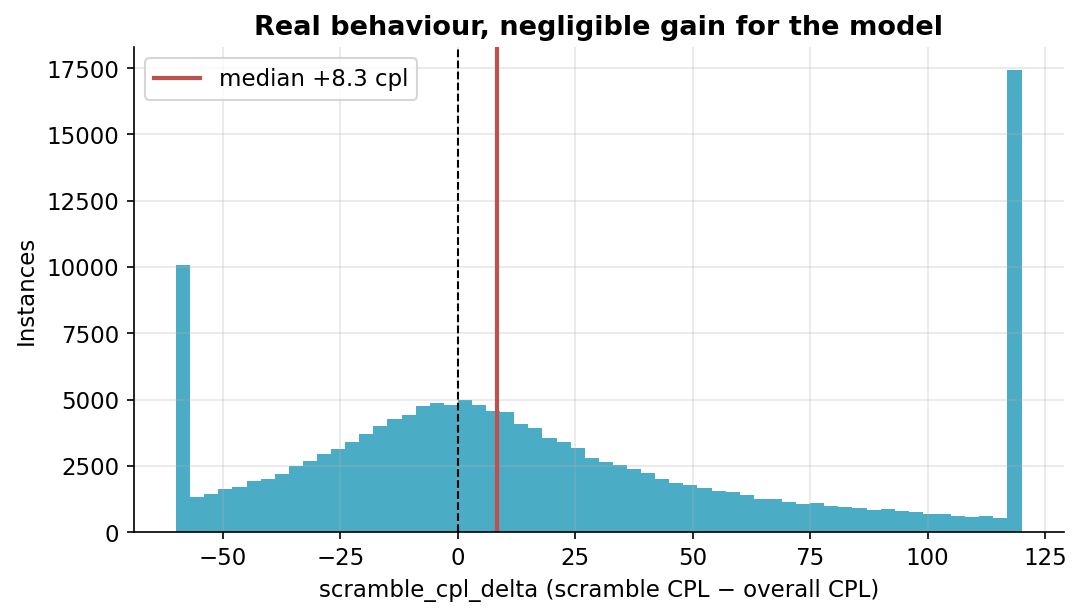

In [4]:
feats = pd.read_parquet(OUT["features"], columns=["has_scramble", "scramble_cpl_delta"])
sc = feats[feats["has_scramble"] == 1]
print(f"scramble present: {len(sc) / len(feats):.1%} of instances; "
      f"scramble_cpl_delta median {sc['scramble_cpl_delta'].median():+.1f}, mean {sc['scramble_cpl_delta'].mean():+.1f} cpl")

s = A["scramble_ablation"]
ci = A["bootstrap"]["no_scramble - full"]
effect = pd.DataFrame({
    "overall MAE": [s["without"]["overall"], s["with"]["overall"]],
    f"{LABELS[0]} MAE": [s["without"][LABELS[0]], s["with"][LABELS[0]]],
    f"{LABELS[-1]} MAE": [s["without"][LABELS[-1]], s["with"][LABELS[-1]]],
}, index=[f"without the scramble block ({s['n_dropped']} features)", "with it (full model)"]).round(1)
display(effect)
print(f"gain from the scramble block: {ci['diff']:.2f} Elo (95% CI {ci['lo']:.2f} .. {ci['hi']:.2f})")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(sc["scramble_cpl_delta"].clip(-60, 120), bins=60, color="#4bacc6")
ax.axvline(0, color="k", ls="--", lw=1)
ax.axvline(sc["scramble_cpl_delta"].median(), color="#c0504d", lw=2,
           label=f"median {sc['scramble_cpl_delta'].median():+.1f} cpl")
ax.set(xlabel="scramble_cpl_delta (scramble CPL − overall CPL)", ylabel="Instances",
       title="Real behaviour, negligible gain for the model")
ax.legend()
show(save_fig(fig, "limits_scramble", FIG))

**Reading it — no useful gain.** The behaviour is real (median +8 cpl per move under 30 s), but the
whole scramble block improves overall MAE by only about **0.2 Elo** and leaves the two extreme bands
unchanged. (Its CI excludes zero, but it only reflects test-set sampling with the models fixed; in
practice the effect is nil.) A plausible explanation — not tested directly — is that the ordinary
clock and move-quality features already carry the same information.

## 2c. The interval — band-conditional (Mondrian) conformal correction

This one targets the *interval*, not the point estimate (it cannot change the bias by
construction). Notebook 04 showed that the interval under-covers the extremes (about 78% / 80%).
**Mondrian CQR** computes a separate conformal correction for each rating band. At prediction time the true band is
unknown, so the only legal choice is the band of the *predicted* rating. Does that fix coverage for
the true extreme bands?

,band,plain,n,mondrian,correction (Elo),calib rows in this predicted band,true-band rows predicted into the same band (%)
0,0-1200,78.4,21267,77.8,20.395566,5431,35.7
1,1200-1400,95.2,15603,95.7,17.854059,9162,28.2
2,1400-1600,97.8,19149,97.9,24.216885,13158,34.2
3,1600-1800,98.6,19834,98.4,36.734495,12752,32.4
4,1800-2000,95.1,17479,94.9,46.591864,9212,27.4
5,2000-3000,80.2,27181,80.9,19.146183,9409,52.4


plain (global) correction: 27.1 Elo


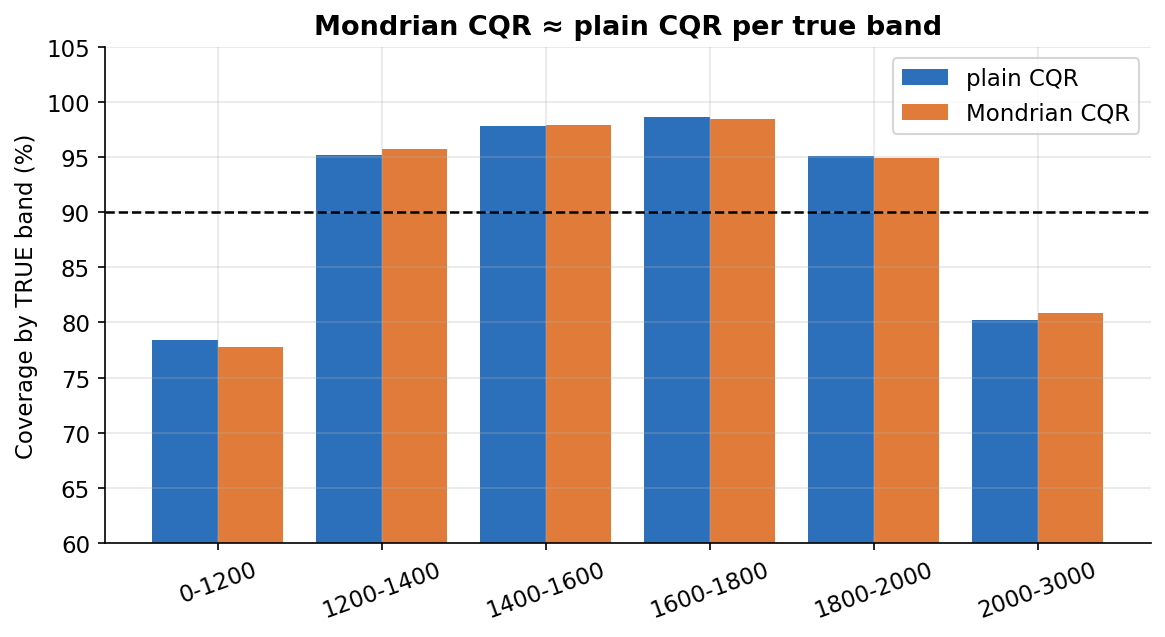

In [5]:
pb = pd.DataFrame(A["coverage_by_band_plain"])[["band", "coverage", "n"]].rename(columns={"coverage": "plain"})
mb = pd.DataFrame(A["coverage_by_band_mondrian"])[["band", "coverage"]].rename(columns={"coverage": "mondrian"})
cb = pb.merge(mb, on="band")
cb["correction (Elo)"] = [A["mondrian_corrections"][str(i)][0] for i in range(len(cb))]
cb["plain"] = (cb["plain"] * 100).round(1); cb["mondrian"] = (cb["mondrian"] * 100).round(1)

diag = A["mondrian_diagnostics"]
ct = np.array(diag["test_true_by_predicted_band"])      # rows: true band, cols: predicted band
cb["calib rows in this predicted band"] = diag["calib_rows_by_predicted_band"]
cb["true-band rows predicted into the same band (%)"] = (np.diag(ct) / ct.sum(1) * 100).round(1)
display(cb)
print(f"plain (global) correction: {A['conformal_correction'][0]:.1f} Elo")

x = np.arange(len(cb))
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(x - 0.2, cb["plain"], width=0.4, label="plain CQR", color="#2c6fbb")
ax.bar(x + 0.2, cb["mondrian"], width=0.4, label="Mondrian CQR", color="#e07b39")
ax.axhline(90, color="k", ls="--", lw=1.2)
ax.set_xticks(x); ax.set_xticklabels(cb["band"], rotation=20)
ax.set(ylabel="Coverage by TRUE band (%)", title="Mondrian CQR ≈ plain CQR per true band", ylim=(60, 105))
ax.legend()
show(save_fig(fig, "limits_mondrian", FIG))

**Reading it — does not restore extreme-band coverage.** Coverage by *true* band is almost
identical under plain and Mondrian CQR. The extreme *predicted* bands are not empty — each has thousands of calibration rows and its
own correction — so this is not a sample-size problem. The problem is **who lands in them**: because
predictions are pulled toward the centre, only about a third of the true below-1200 players and
about half of the true 2000+ players are *predicted* into their own band (last column). The rest
are predicted into interior bands, whose correction is set by the mid-rated players who dominate
those bands, and it is too small for them. Conditioning on the prediction targets coverage *per
predicted band*; it cannot target the true band, which is exactly what is unknown at test time.

## 3. What several games do to the tail

At the single-game level there is no leftover shrinkage to undo, and reweighting only moves
error between rating levels: one game is weak evidence, and a good estimate answers weak evidence
by hedging toward the average. The remedy is **more evidence per player**.
For the test players with at least 5 games, we compare one game, the plain average of 5 games, and
the K-aware recalibrated average from notebook 04 — mean residual per true band.

,n_players,single_mae,naive_mae,recal_mae,single_bias,naive_bias,recal_bias
band,,,,,,,
0-1200,831,313.0,300.7,207.9,298.2,299.9,186.8
1200-1400,596,220.3,175.4,162.9,161.7,160.3,106.2
1400-1600,750,187.2,122.3,156.1,48.4,47.9,22.6
1600-1800,875,194.7,126.8,163.4,-52.2,-52.1,-42.6
1800-2000,861,222.5,165.1,173.9,-136.2,-136.7,-87.6
2000-3000,1579,283.8,251.4,178.8,-247.6,-245.9,-110.7


players: 5,492; MAE one game 244.3 -> average 199.6 -> recalibrated 175.1  (gain 24.4, 95% CI 22.2 .. 26.8)


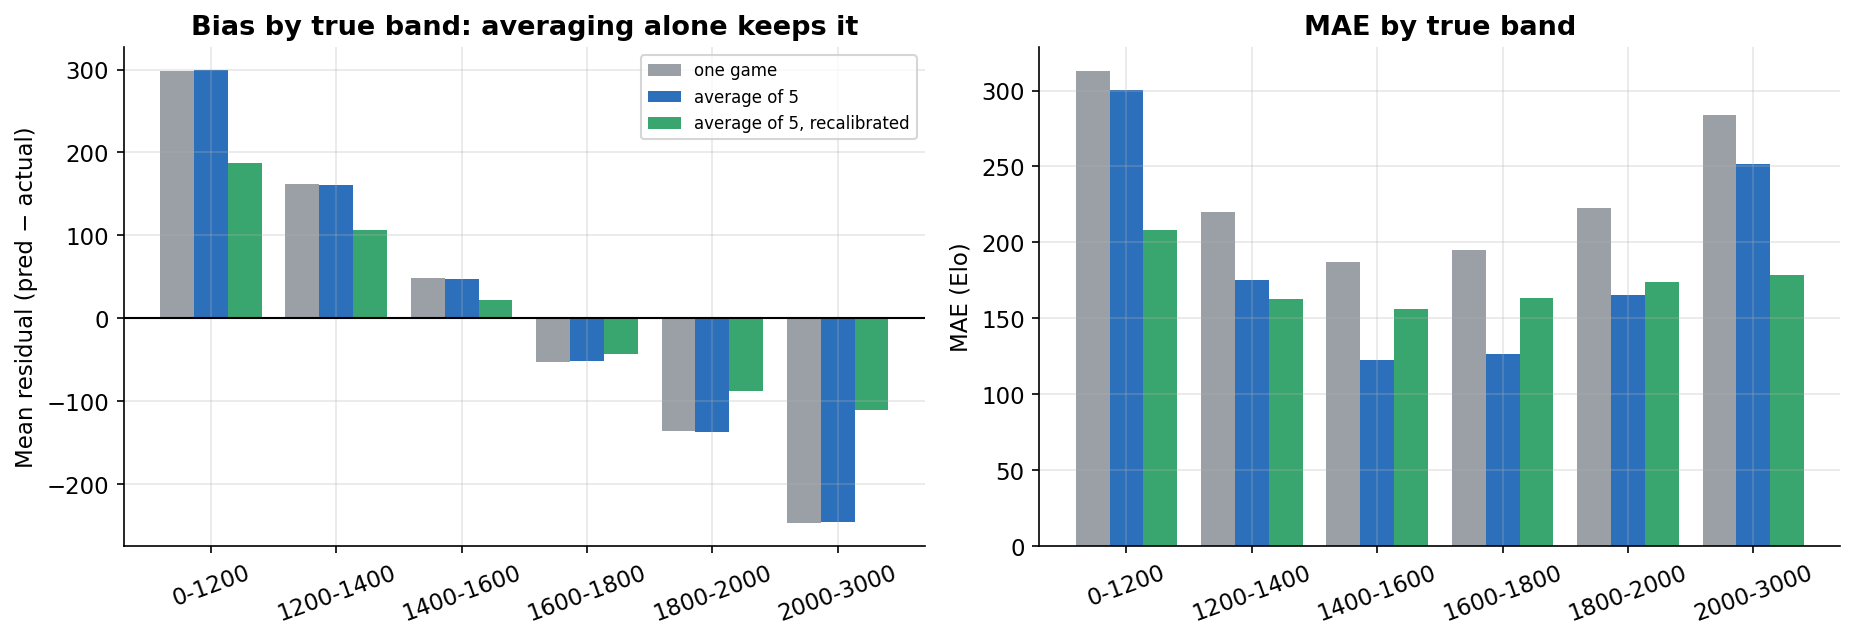

In [6]:
k5 = A["aggregate_bands_k5"]
tbl = pd.DataFrame(k5["bands"]).set_index("band")
display(tbl.round(1))
ci = k5["naive_minus_recal_ci"]
print(f"players: {k5['n_players']:,}; MAE one game {k5['single_mae']:.1f} -> average {k5['naive_mae']:.1f} "
      f"-> recalibrated {k5['recal_mae']:.1f}  (gain {ci['diff']:.1f}, 95% CI {ci['lo']:.1f} .. {ci['hi']:.1f})")

x = np.arange(len(tbl))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
for col, lab, color, off in [("single", "one game", "#9aa0a6", -0.27), ("naive", "average of 5", "#2c6fbb", 0.0),
                             ("recal", "average of 5, recalibrated", "#3aa66f", 0.27)]:
    ax1.bar(x + off, tbl[f"{col}_bias"], width=0.27, color=color, label=lab)
    ax2.bar(x + off, tbl[f"{col}_mae"], width=0.27, color=color, label=lab)
ax1.axhline(0, color="k", lw=1)
for ax, ylab, title in [(ax1, "Mean residual (pred − actual)", "Bias by true band: averaging alone keeps it"),
                        (ax2, "MAE (Elo)", "MAE by true band")]:
    ax.set_xticks(x); ax.set_xticklabels(tbl.index, rotation=20); ax.set(ylabel=ylab, title=title)
ax1.legend(fontsize=8)
fig.tight_layout()
show(save_fig(fig, "limits_aggregation", FIG))

**Reading it.** Averaging 5 games lowers MAE (about 244 → 200) by removing game-to-game noise, but
the **bias in the extreme bands does not move** (about +298 → +300 below 1200, about −248 → −246 at
2000+): every one of those games was pulled toward the centre, and so is their average. The
**K-aware recalibration** — fit on held-out calibration players — reduces that bias to about **+187**
and **−111** and brings MAE to about 175 (a gain of about 24 Elo over the plain average, with a
tight CI).

It is a **trade-off**, not a free lunch: stretching the averaged predictions away from the centre
*worsens* the two central bands by about 28–29% (1400–1600: about 122 → 156 MAE; 1600–1800: about
127 → 163) while improving the extreme bands by far more (below 1200: about 301 → 208; 2000+: about
251 → 179). Overall the recalibrated
estimate is better, and its errors are spread more evenly across rating levels — which is what a
platform needs if the estimate is used to place players of every strength.

So the tail error is not an unfixable floor. At the single-game level it is the calibrated
response to weak evidence (fixes 1–3 fail); with more games, part of it can be removed — but only if
the combined estimate is adjusted for how much evidence it rests on. The remaining bias at K = 5
reflects what five games still cannot resolve.

## 4. Robustness checks

**(a) Leakage through shared games.** The split is grouped by player, not by game, so a test
player's *opponent* may sit in the training data. Both sides of a game share game-level features
(length, opening code, time control, phase lengths), and the opponent's rating is close to the
player's (matchmaking). If the model had memorised games, test rows whose opponent's row is in the
**training** split would be predicted better. (Which split the opponent is in is decided at random,
independently of the test player, so this is a fair comparison.) **(b) Error vs game length:**
longer games give more moves to judge.

test rows whose opponent's row is in the training split: 65,639  MAE 238.1
test rows whose opponent's row is not                  : 54,874  MAE 240.4
difference -2.2 Elo (95% CI -4.4 .. -0.2)


,moves,n,mae,mean_residual
0,0-19,15816,260.4,-18.7
1,20-29,38878,246.5,-4.2
2,30-39,31900,234.8,-2.0
3,40-59,26680,227.3,3.5
4,60+,7239,215.8,3.1


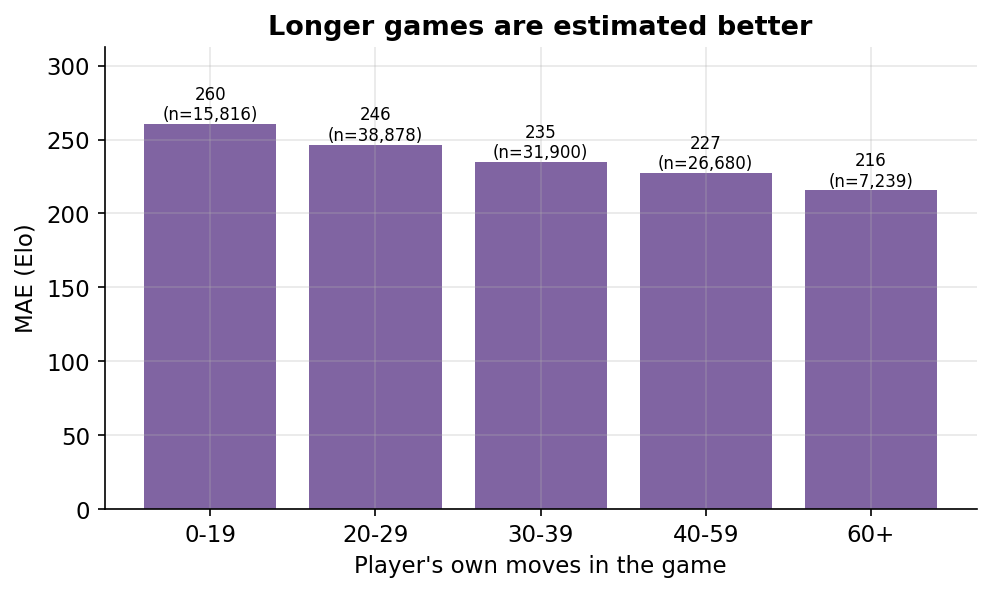

In [7]:
pc = A["partner_check"]
print(f"test rows whose opponent's row is in the training split: {pc['n_seen']:,}  MAE {pc['mae_seen']:.1f}")
print(f"test rows whose opponent's row is not                  : {pc['n_unseen']:,}  MAE {pc['mae_unseen']:.1f}")
d = pc["diff_ci"]
print(f"difference {d['diff']:+.1f} Elo (95% CI {d['lo']:+.1f} .. {d['hi']:+.1f})")

bl = pd.DataFrame(A["residual_by_length"])
display(bl.round(1))
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(bl["moves"], bl["mae"], color="#8064a2")
for i, (v, n) in enumerate(zip(bl["mae"], bl["n"])):
    ax.text(i, v, f"{v:.0f}\n(n={n:,})", ha="center", va="bottom", fontsize=8)
ax.set(xlabel="Player's own moves in the game", ylabel="MAE (Elo)", title="Longer games are estimated better",
       ylim=(0, bl["mae"].max() * 1.2))
show(save_fig(fig, "limits_error_by_length", FIG))

**Reading it.** Rows whose opponent's row was trained on are predicted **slightly better**: by
2.2 Elo (95% CI 0.2 to 4.4). So there is a small leak through shared games: the model has partly
learned game-level details of training games, and the opponent's rating is close to the player's.
Its size is small: on the test rows that share no game with training the MAE is 240.4, against
239.1 on all test rows, so the headline is optimistic by about 1 Elo. The confirmatory hold-out
(section 6) has no game in common with the development data at all. This checks one channel;
it cannot prove that no other leakage exists. (An earlier version of this check counted validation
games as "seen" too, although no model is fit on them, and found −0.6 Elo, CI −3.0 to +1.5.)

And error falls steadily with game length — from about 260 for games where the player
made fewer than 20 moves to about 216 for 60+ moves. This is consistent with "more moves, more
evidence" (the same story as aggregation), but it is descriptive: game length also varies with the
players and the time control, so it is not a controlled comparison.

**(c) Confidence intervals.** The main MAE comparisons were bootstrapped by player (1,000
resamples of the test players, models held fixed); the K = 5 recalibration CI above also refits the
recalibration on resampled calibration players:

In [8]:
boot = pd.DataFrame([(k, v["diff"], v["lo"], v["hi"]) for k, v in A["bootstrap"].items() if " - " in k],
                    columns=["comparison (MAE a − MAE b)", "difference", "95% CI low", "95% CI high"]).round(2)
display(boot)

,comparison (MAE a − MAE b),difference,95% CI low,95% CI high
0,baseline - full,54.24,52.71,55.83
1,no_engine - full,33.57,32.45,34.64
2,no_clock - full,9.15,8.51,9.85
3,no_opening - full,8.20,7.63,8.82
4,no_style - full,7.88,7.38,8.38
5,no_scramble - full,0.24,0.09,0.40


**(d) Two sensitivity checks.** *Dependent games:* a player contributes several games, so the
conformal guarantee does not formally hold for rows; keeping one random game per player in
calibration and test makes the scores independent across players. *Sampling design:* the data mix
a uniform reservoir sample with a player cohort (every game of about 0.5% of players), which gives
cohort games a higher chance of inclusion; restricting the test rows to games from the uniform
sample removes the cohort-only games.

In [9]:
og, ro = A["cqr_one_game_per_player"], A["reservoir_only"]
print(f"CQR with one game per player: coverage {og['coverage']:.1%} "
      f"(range {og['coverage_min']:.1%}-{og['coverage_max']:.1%} over {og['draws']} draws), width {og['mean_width']:.0f}")
print(f"test rows from the uniform sample only: {ro['n_test']:,} ({ro['n_excluded']:,} cohort-only rows dropped): "
      f"MAE {ro['mae']:.1f} (all rows {A['full_mae']:.1f}), no-engine baseline {ro['baseline_mae']:.1f}, "
      f"coverage {ro['coverage']:.1%}")

CQR with one game per player: coverage 90.1% (range 89.9%-90.2% over 20 draws), width 983
test rows from the uniform sample only: 119,141 (1,372 cohort-only rows dropped): MAE 239.1 (all rows 239.1), no-engine baseline 293.4, coverage 89.9%


**Reading it.** Neither changes the picture: 90.1% coverage with one game per player, and the same
MAE (239.1) and coverage on the uniform-sample rows — the cohort adds only about 1% of the test rows.

## 5. The worst single-game misses

The 20 test games with the largest errors (`reports/largest_residuals.csv`, written by
`src.evaluate`; no username or game id is stored).

,rating,pred,residual,player_moves,cpl_mean,case
0,2662,1156.0,-1506.0,22,106.0,"high-rated, under-predicted"
1,561,2046.0,1485.0,40,56.0,"low-rated, over-predicted"
2,477,1959.0,1482.0,18,65.0,"low-rated, over-predicted"
3,805,2232.0,1427.0,67,46.0,"low-rated, over-predicted"
4,2662,1270.0,-1392.0,41,78.0,"high-rated, under-predicted"
5,635,2020.0,1385.0,35,15.0,"low-rated, over-predicted"
6,2526,1151.0,-1375.0,31,88.0,"high-rated, under-predicted"
7,1054,2401.0,1347.0,36,26.0,"low-rated, over-predicted"
8,912,2258.0,1346.0,45,17.0,"low-rated, over-predicted"
9,858,2182.0,1324.0,54,76.0,"low-rated, over-predicted"



case breakdown:
case
low-rated, over-predicted      13
high-rated, under-predicted     7


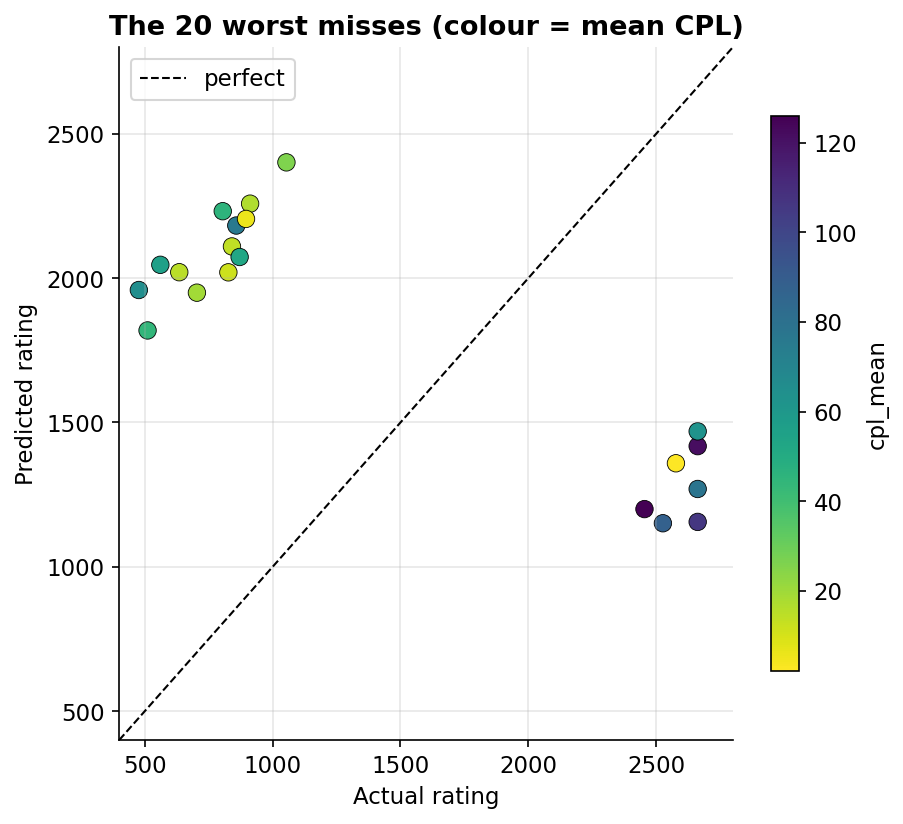

In [10]:
lr = pd.read_csv(OUT["largest_residuals"])
view = lr[["rating", "pred", "residual", "player_moves", "cpl_mean", "case"]].copy()
view[["pred", "residual", "cpl_mean"]] = view[["pred", "residual", "cpl_mean"]].round(0)
display(view.head(12))
print("\ncase breakdown:")
print(lr["case"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(6.6, 6))
pts = ax.scatter(lr["rating"], lr["pred"], c=lr["cpl_mean"], cmap="viridis_r", s=70, edgecolor="k", linewidth=0.4)
ax.plot([400, 2800], [400, 2800], "k--", lw=1, label="perfect")
ax.set(xlim=(400, 2800), ylim=(400, 2800), xlabel="Actual rating", ylabel="Predicted rating",
       title="The 20 worst misses (colour = mean CPL)")
ax.legend(loc="upper left")
fig.colorbar(pts, ax=ax, shrink=0.8, label="cpl_mean")
show(save_fig(fig, "limits_worst_cases", FIG))

**Reading it.** The worst misses are games that look like a very different rating. Most of the
under-predicted high-rated players had a poor game (high mean CPL); many of the over-predicted
low-rated players had an unusually clean one (low CPL), though not all — the model also uses clock
and style features. A few are very short games with only a handful of scored moves. Several misses
share exactly the same rating (see the `rating` column) and are very likely the same account playing
many games unlike its rating (for example, deliberately casual games); a single-game model cannot
detect that, and per-player aggregation would at least pool such games. These are cases where one
game genuinely points to the wrong rating, not bugs to fix.

## 6. The confirmatory hold-out

Every number above comes from the development test split, which was scored many times while the
method took shape — so they are development estimates. To get a number that no decision depended
on, we froze the method, wrote a protocol (`reports/HOLDOUT_PROTOCOL.md`) and committed it before
extracting any data, then scored the frozen models **once** (`python -m src.holdout`): every
eligible game of **2025-05-31**, 26 days after the development window, keeping only the rows of
players who appear nowhere in the development data. No hold-out game is in the development data,
so the shared-game leak of section 4 cannot reach it.

In [11]:
H = json.loads(Path(OUT["holdout_results"]).read_text(encoding="utf-8"))
hf = json.loads(Path(OUT["data_funnel"]).read_text(encoding="utf-8"))["holdout_prepare"]
print(f"hold-out: {H['n_rows']:,} rows of {H['n_players']:,} new players "
      f"({hf['instances_of_development_players']:,} rows of development players dropped); "
      f"rating mean {H['rating_mean']:.0f} (sd {H['rating_sd']:.0f})")
b = H["bootstrap"]
iv = H["interval"]
dev_cov = {r["band"]: r["coverage"] for r in A["coverage_by_band_mondrian"]}
rows = [
    ("predict the development training mean", 364.8, H["mae"]["predict_mean"]),
    ("no-engine baseline", A["baseline_mae"], H["mae"]["baseline"]),
    ("full model (headline)", A["full_mae"], H["mae"]["full"]),
    ("gain over the no-engine baseline", A["baseline_mae"] - A["full_mae"], b["baseline - full"]["diff"]),
    ("90% coverage, Mondrian (%)", A["coverage_cqr_mondrian"] * 100, iv["cqr_mondrian"]["coverage"] * 100),
    ("coverage below 1200 (%)", dev_cov["0-1200"] * 100, iv["cqr_mondrian"]["by_band"][0]["coverage"] * 100),
    ("coverage at 2000+ (%)", dev_cov["2000-3000"] * 100, iv["cqr_mondrian"]["by_band"][-1]["coverage"] * 100),
]
km = {m["k"]: m for m in H["matched_aggregation"]}
kd = {m["k"]: m for m in A["matched_aggregation"]}
if 10 in km:
    rows += [("K = 10: plain average", kd[10]["naive_mae"], km[10]["naive_mae"]),
             ("K = 10: recalibrated", kd[10]["recal_mae"], km[10]["recal_mae"])]
display(pd.DataFrame(rows, columns=["", "development test", "hold-out"]).set_index("").round(1))
f = b["full"]
g = b["baseline - full"]
print(f"hold-out full-model MAE {f['mae']:.1f} (95% CI {f['lo']:.1f}-{f['hi']:.1f}); "
      f"gain over the baseline {g['diff']:.1f} (95% CI {g['lo']:.1f}-{g['hi']:.1f})")

tot_h = sum(r["n"] for r in H["residual_by_band"]); tot_d = sum(r["n"] for r in A["residual_by_band"])
bands = pd.DataFrame({
    "band": [r["band"] for r in H["residual_by_band"]],
    "share dev %": [r["n"] / tot_d * 100 for r in A["residual_by_band"]],
    "share hold-out %": [r["n"] / tot_h * 100 for r in H["residual_by_band"]],
    "MAE dev": [r["mae"] for r in A["residual_by_band"]],
    "MAE hold-out": [r["mae"] for r in H["residual_by_band"]],
}).set_index("band").round(1)
display(bands)
reweighted = sum(r["n"] / tot_d * h["mae"] for r, h in zip(A["residual_by_band"], H["residual_by_band"]))
print(f"hold-out band MAEs weighted by the development band shares: {reweighted:.1f}")

hold-out: 124,403 rows of 67,744 new players (122,149 rows of development players dropped); rating mean 1562 (sd 432)


,development test,hold-out
,,
predict the development training mean,364.8,358.9
no-engine baseline,293.4,296.7
full model (headline),239.1,243.9
gain over the no-engine baseline,54.2,52.9
"90% coverage, Mondrian (%)",89.9,89.4
coverage below 1200 (%),77.8,75.4
coverage at 2000+ (%),80.9,80.9
K = 10: plain average,202.0,204.9
K = 10: recalibrated,152.4,167.4


hold-out full-model MAE 243.9 (95% CI 242.4-245.4); gain over the baseline 52.9 (95% CI 51.5-54.2)


,share dev %,share hold-out %,MAE dev,MAE hold-out
band,,,,
0-1200,17.6,21.8,313.0,322.3
1200-1400,12.9,14.9,215.6,218.7
1400-1600,15.9,17.1,186.7,193.1
1600-1800,16.5,16.1,188.4,192.8
1800-2000,14.5,13.7,219.4,220.9
2000-3000,22.6,16.3,281.5,285.0


hold-out band MAEs weighted by the development band shares: 243.9


**Reading it.** The findings hold on data no decision depended on: the same gain over the no-engine
baseline (52.9 against 54.2), about 90% average coverage (89.4%) with the same weak extremes, the
same extreme-band bias, and a clear gain from recalibrating several games (K = 10: 205 → 167).

The error is **about 5 Elo higher** (243.9 against 239.1). It is not the rating mix — the hold-out
has more players below 1200 and fewer at 2000+, but weighting its band MAEs by the development
shares gives the same 243.9 — and not the rating spread, since the mean predictor does *better* on
the hold-out. The MAE is a little higher within every band. About 1 Elo of that is the shared-game
leak the development estimate enjoyed (section 4); the rest fits a population of less active
players (no analysed blitz game in May 1–5) seen 26 days later: their overall bias is +33 Elo,
against −3 in development.

## Limitations

- **Selection bias.** Only games with stored engine evaluations are used (about 9% of blitz
  games) — games someone chose to analyse. Results hold for that population; transfer to
  un-analysed games is untested (it would need our own engine analysis of a random sample).
- **Time window.** The first 15M games of May 2025 = May 1–5. One short window of one month;
  seasonality and rating drift are not studied.
- **Labels.** Lichess ratings (Glicko-2) of new or returning players are provisional and noisy; the
  PGN export does not mark them, so they cannot be identified reliably. Two symptoms: a spike of
  instances at exactly 1500 (the starting rating), and games with a rating gap beyond ±250 that the
  lower-rated player wins more often (notebook 01).
- **Blitz only.** Rapid and classical are not studied.
- **Interval coverage is marginal and approximate.** About 90% on average over test games; about
  78–80% in the extreme bands; games of one player are not independent.
- **Aggregation within five days.** "Several games of a player" come from the same five days; a
  player's strength can change over longer periods. The K-game error is measured against the
  player's average rating over those games, for the most active players.
- **The development test split was reused.** It was scored many times while the method took
  shape, so its numbers are development estimates; the confirmatory hold-out (section 6) gives
  243.9 MAE and 89.4% coverage on new players, about 5 Elo worse.
- **A small leak through shared games** (about 2 Elo on the rows whose opponent was trained on;
  about 1 Elo on the headline).
- **Mixed sampling design.** A uniform sample plus a player cohort; the cohort is about 1% of the
  test rows and removing it changes nothing.

## Takeaways

- **Single game:** there is no leftover linear shrinkage (slope 0.96, CI 0.946–0.976), and the
  extreme-band bias is the cost of weak evidence. Up-weighting rare ratings improves the tails only by making the middle worse
  (overall MAE +6.5), clock-scramble features add about nothing, and Mondrian intervals do not
  restore extreme-band coverage.
- **Several games:** plain averaging reduces noise but keeps the bias; recalibrating the average for
  the number of games cuts the extreme-band bias at K = 5 by about 38% (below 1200) and 55% (2000+),
  and MAE by about 24 Elo — at a cost of about +30 MAE in the central bands.
- **Hold-out:** scored once on new players 26 days later: MAE 243.9 (vs 239.1), the same gain over
  the baseline, 89.4% coverage — the conclusions hold.
- **Robustness:** a small leak through shared games (about 1 Elo on the headline), coverage
  unchanged with one game per player, results unchanged without the cohort games, and the main
  comparisons come with player-clustered confidence intervals.